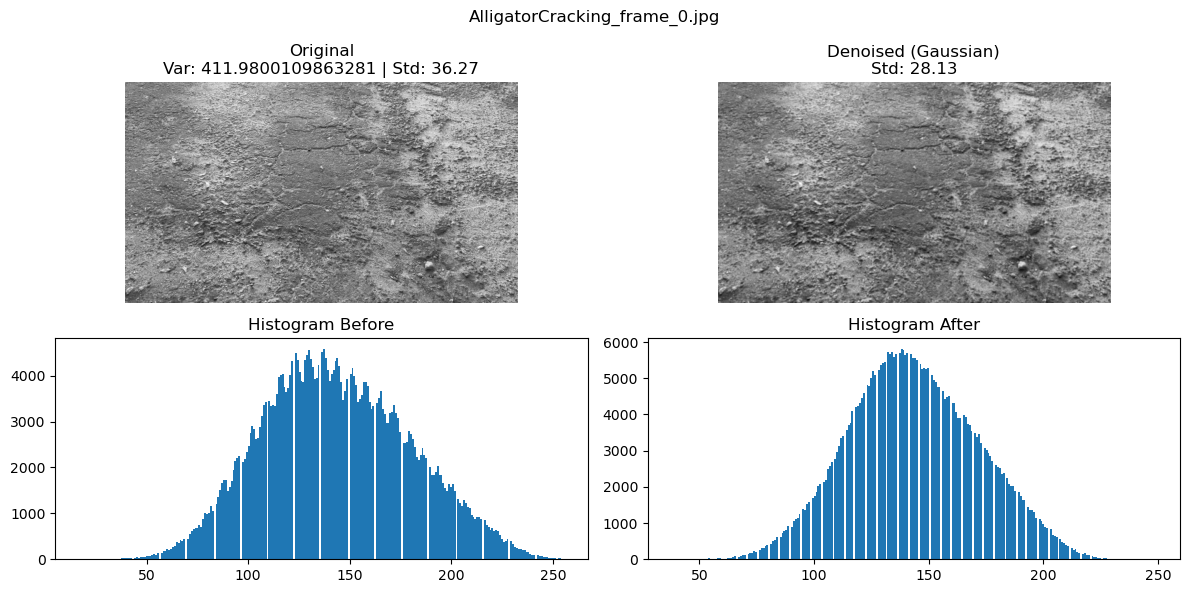

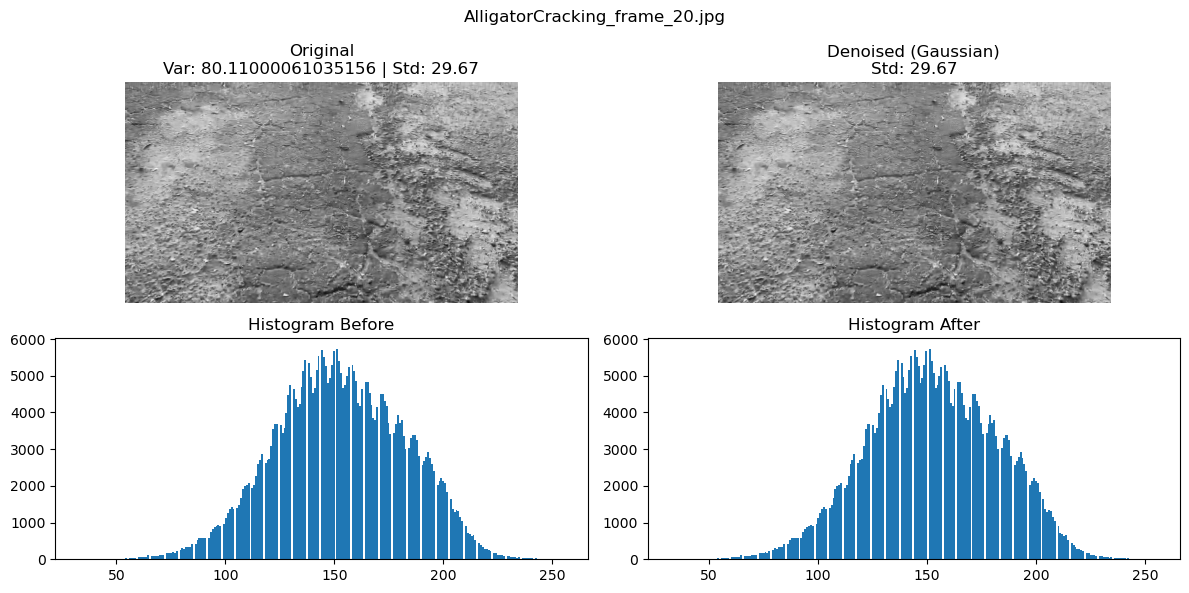

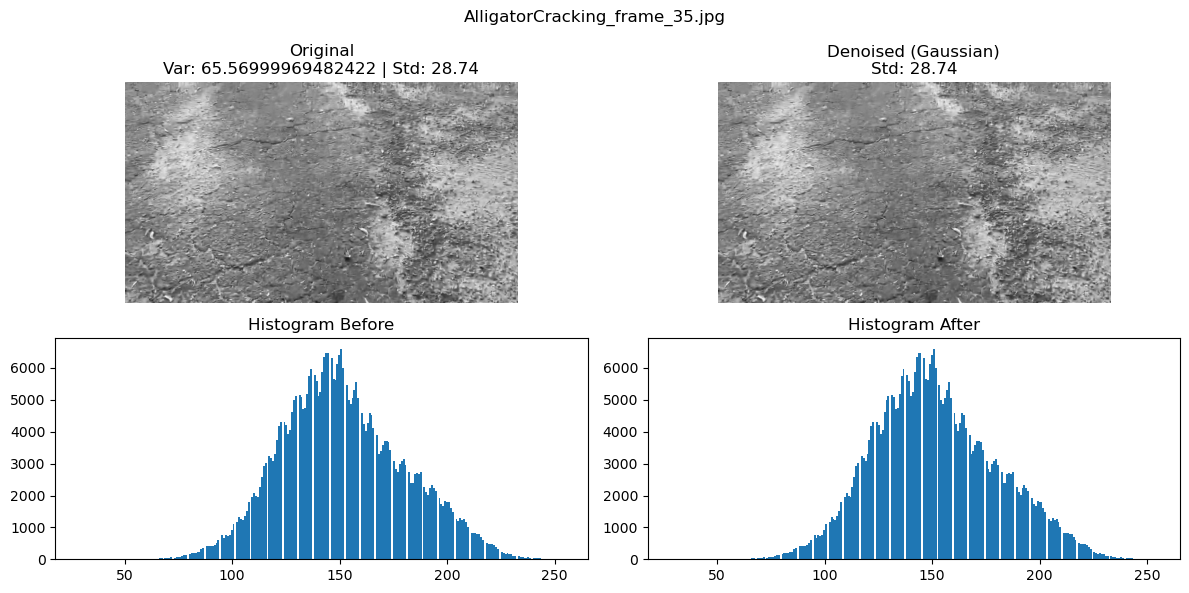

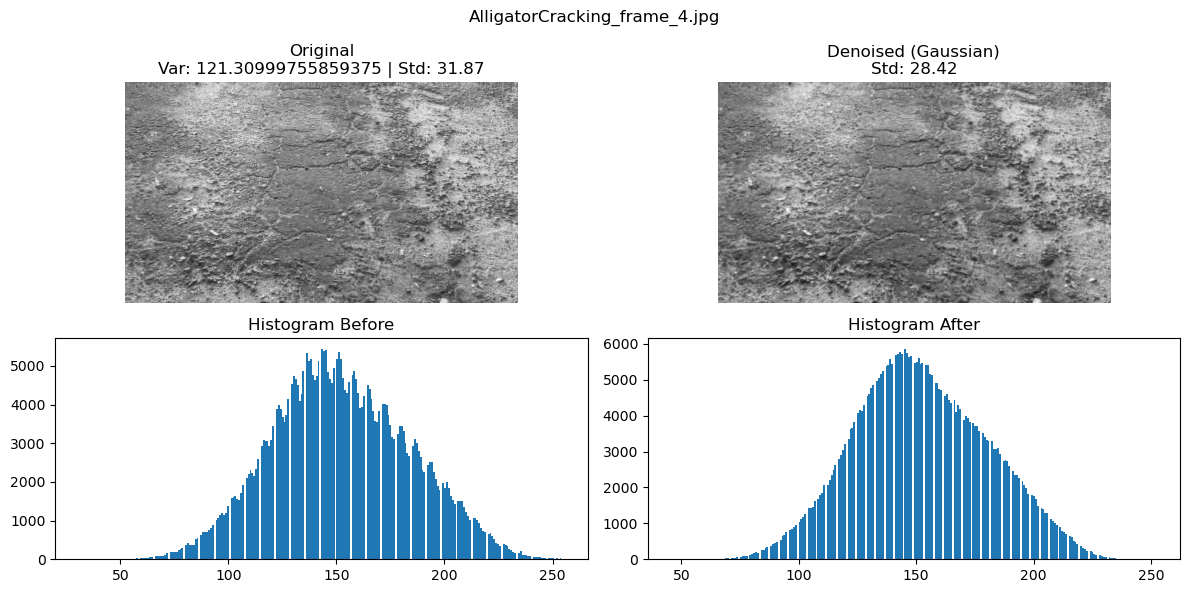

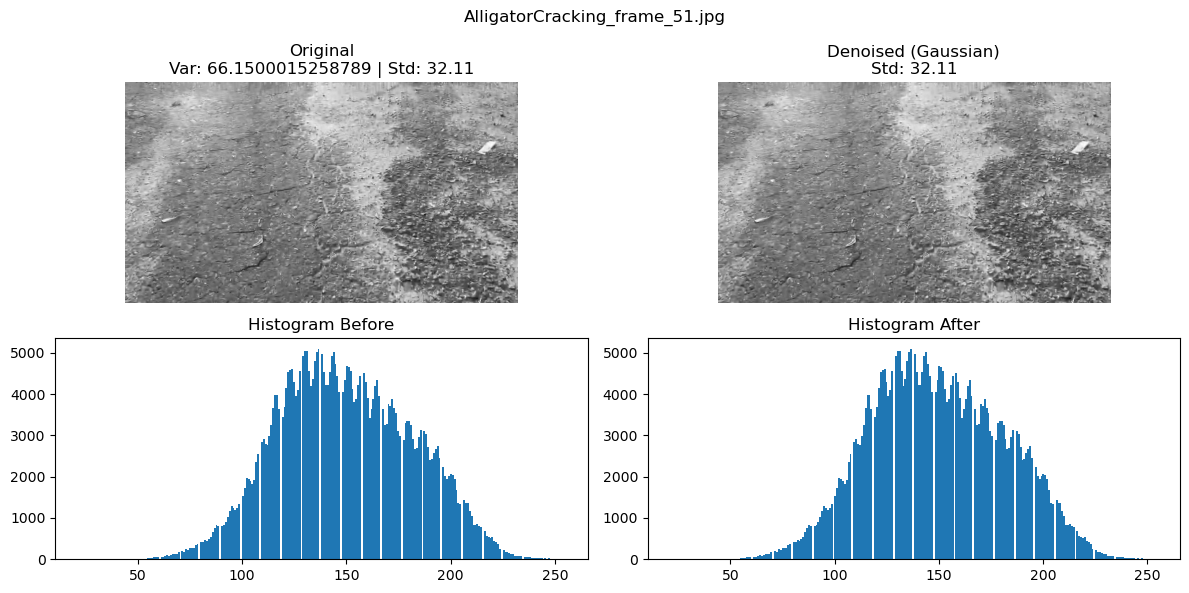

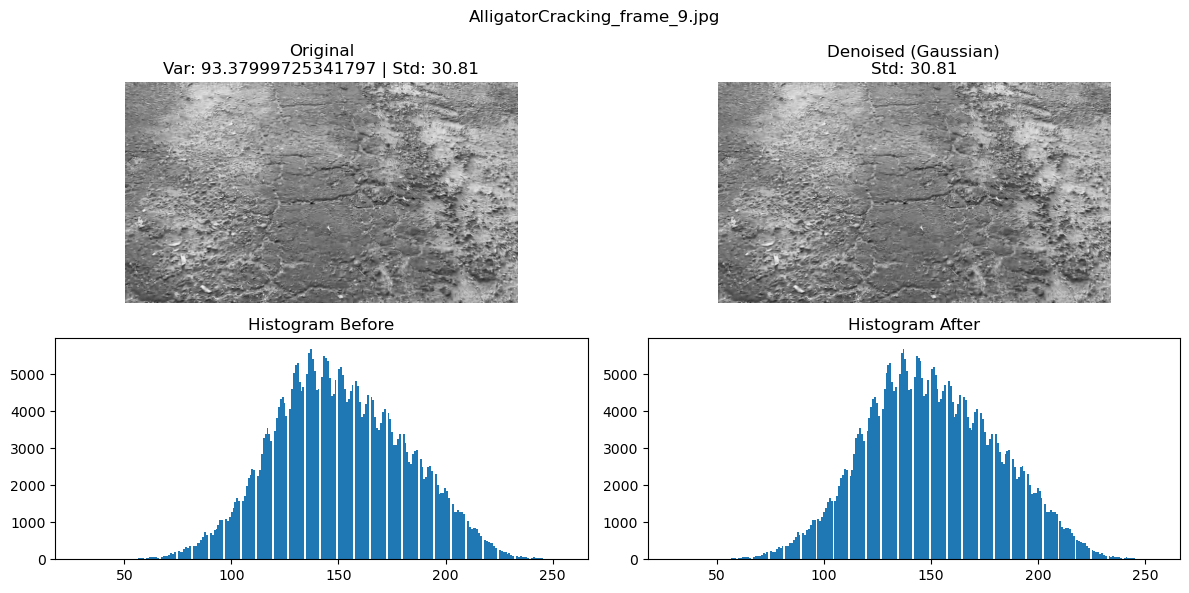

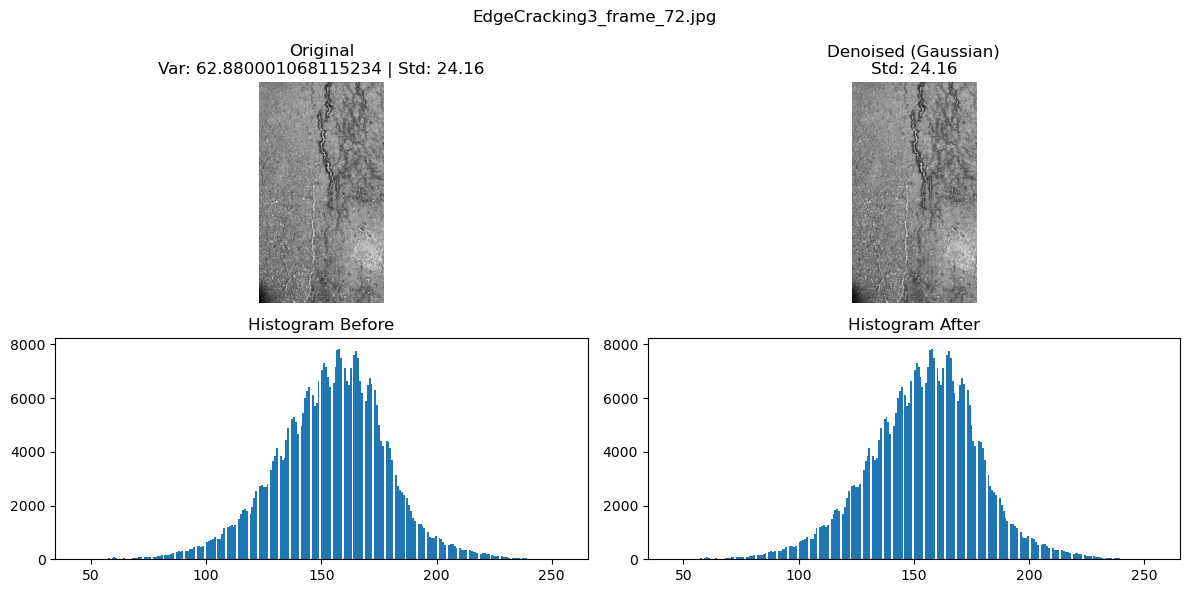

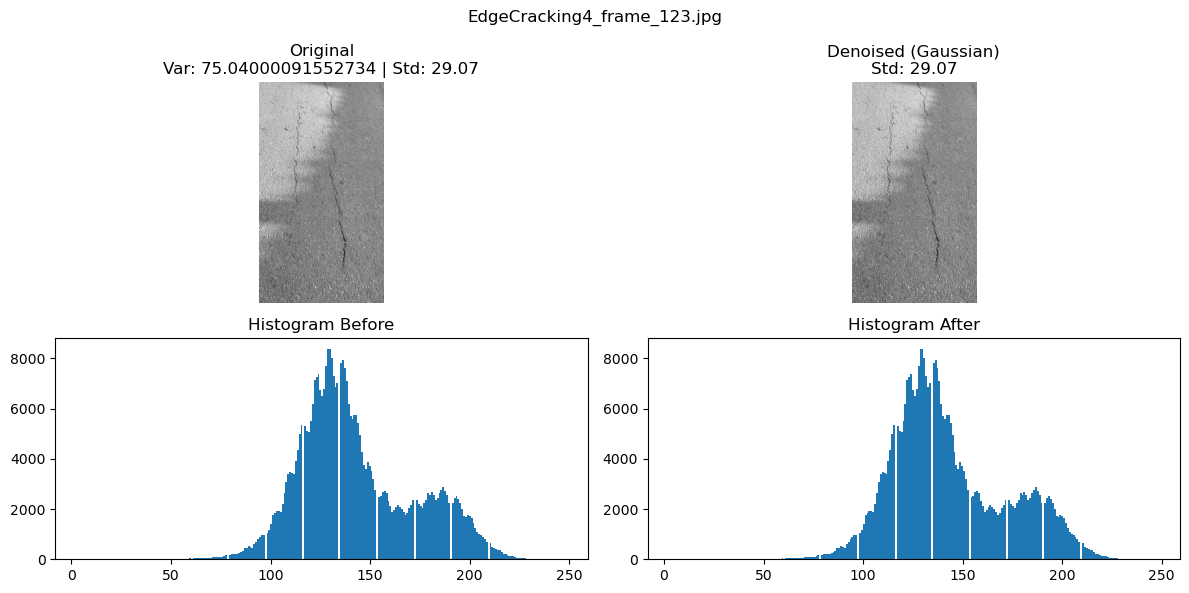

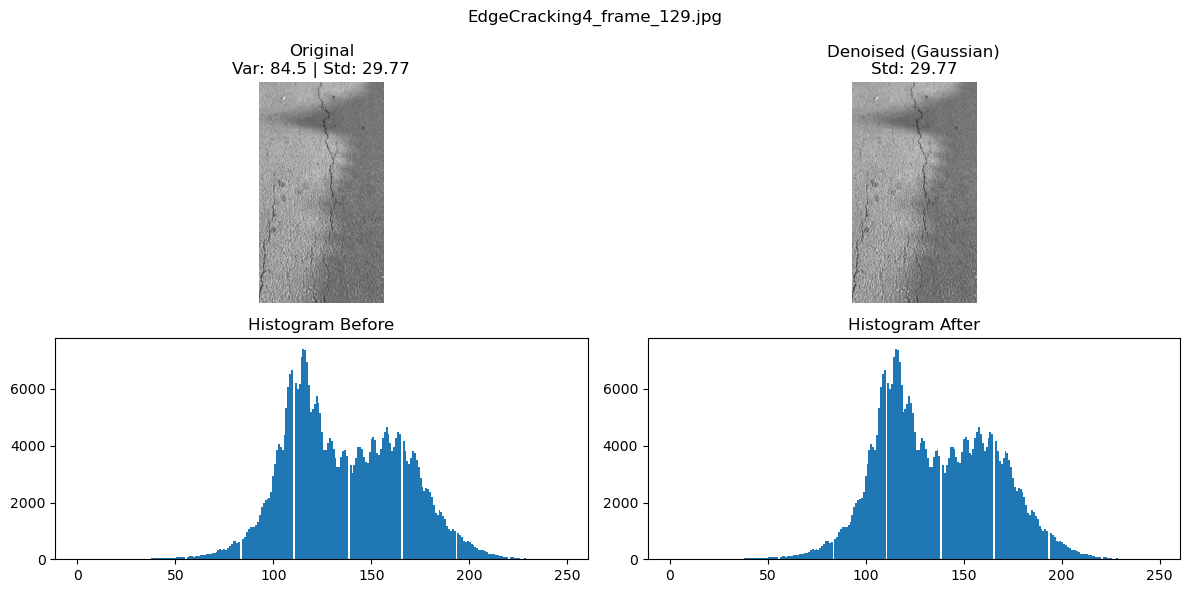

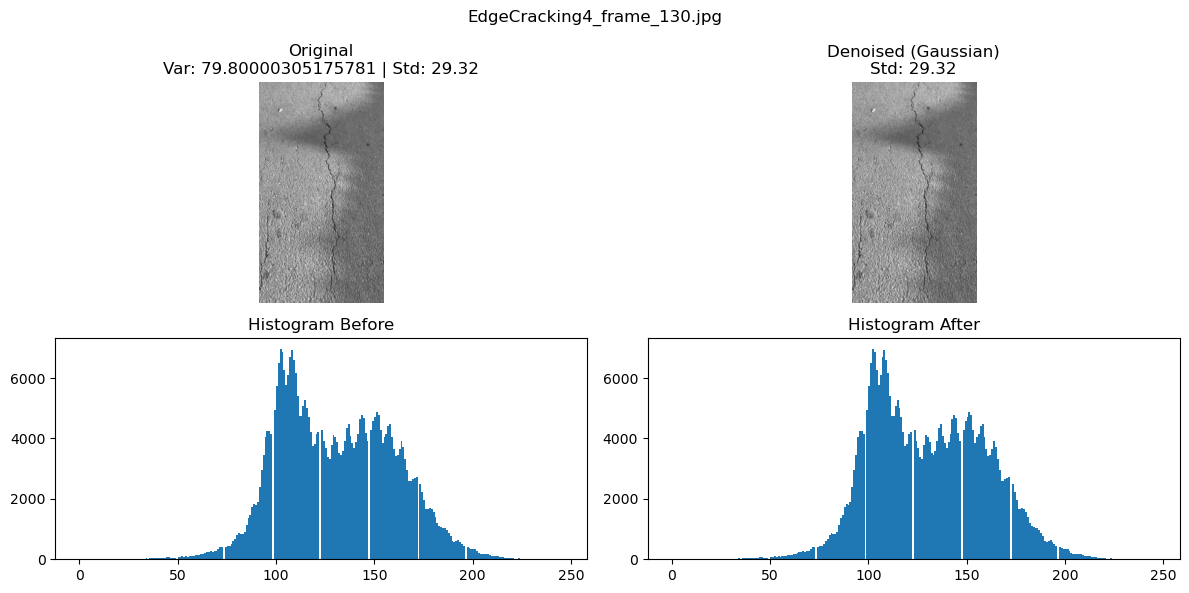

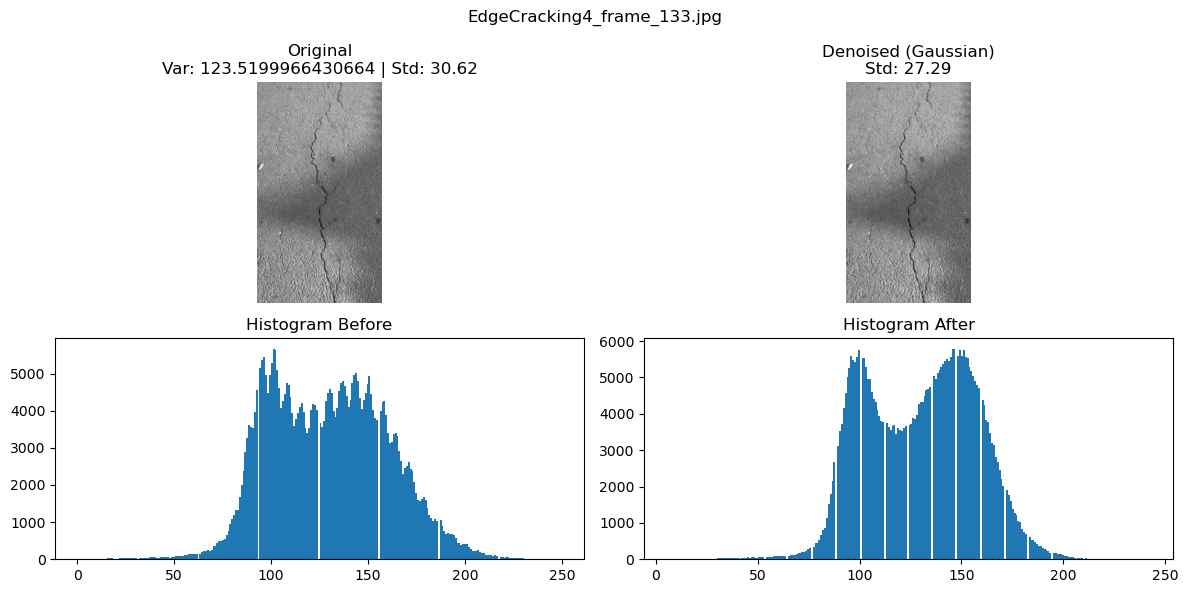

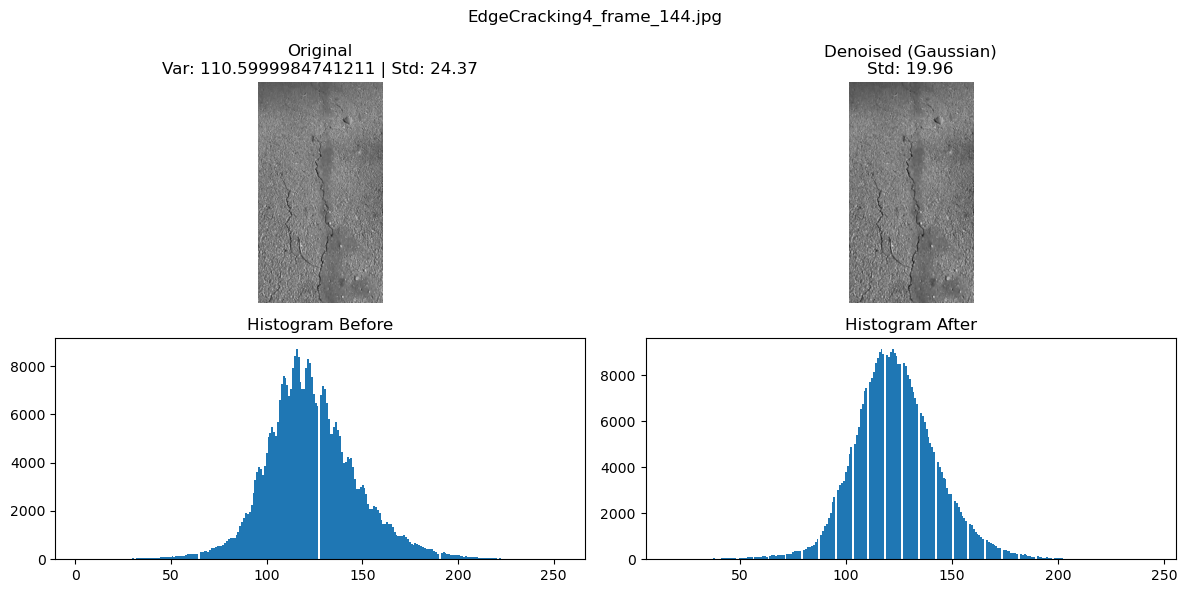

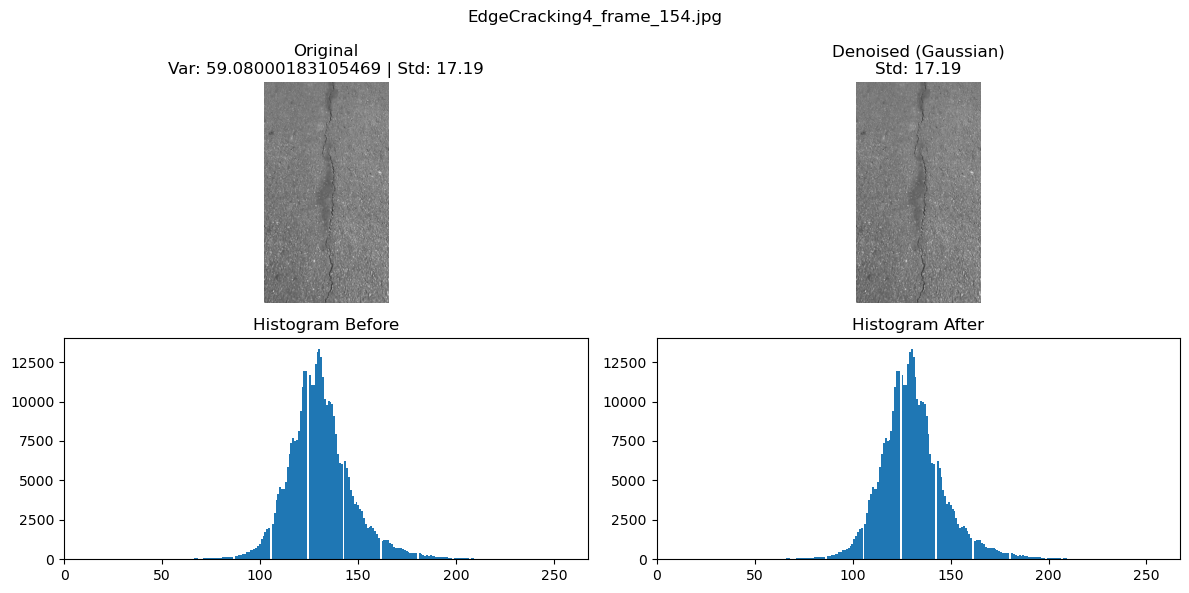

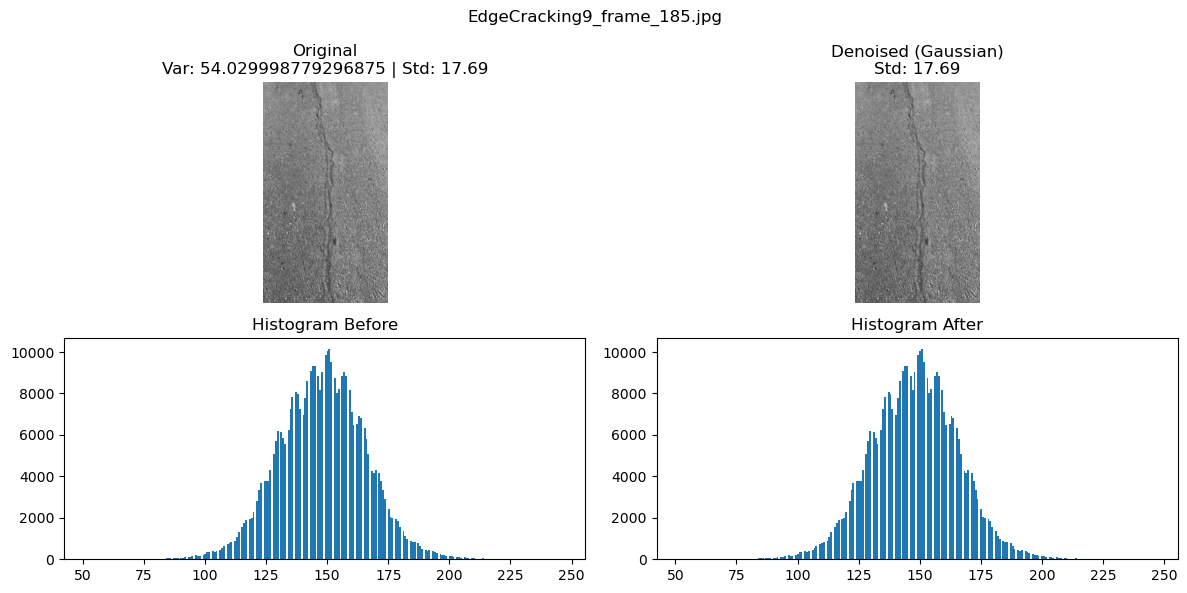

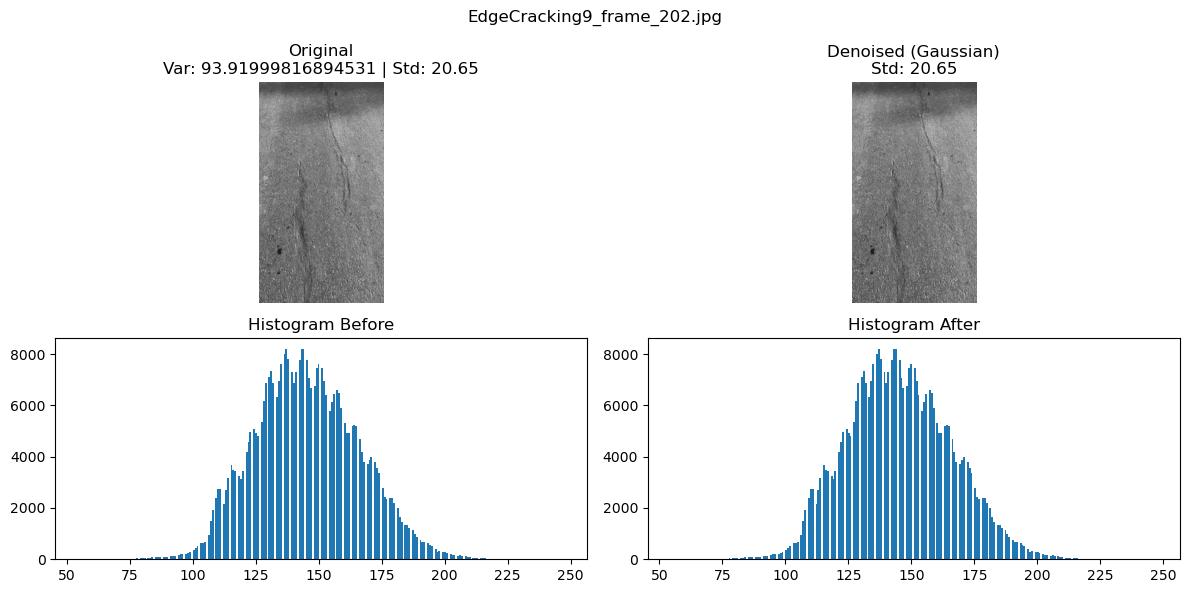

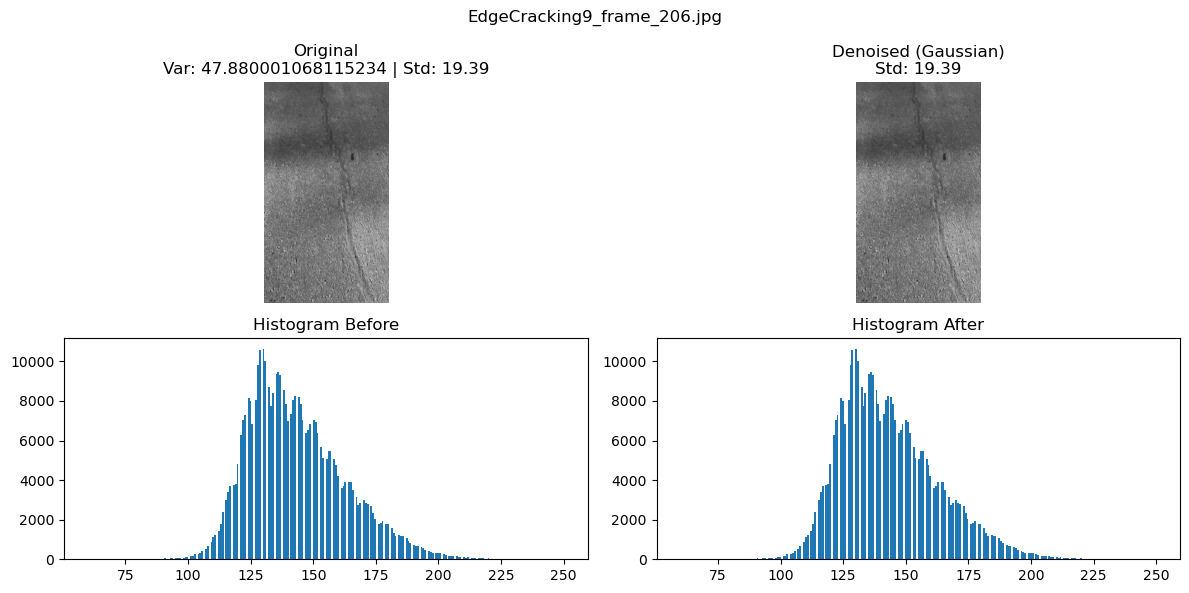

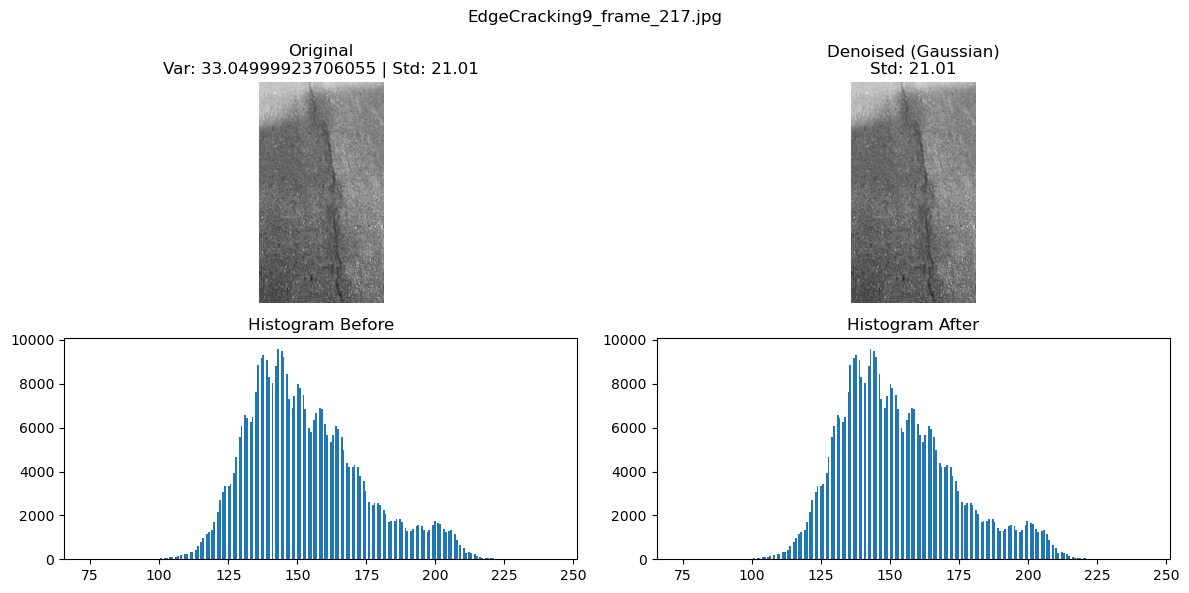

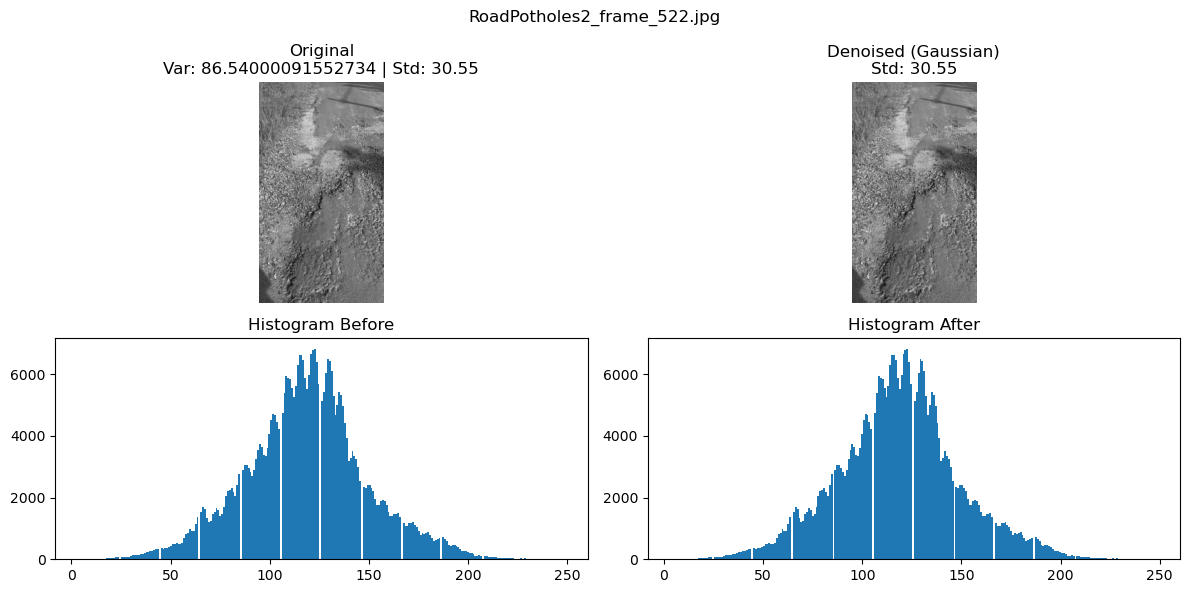

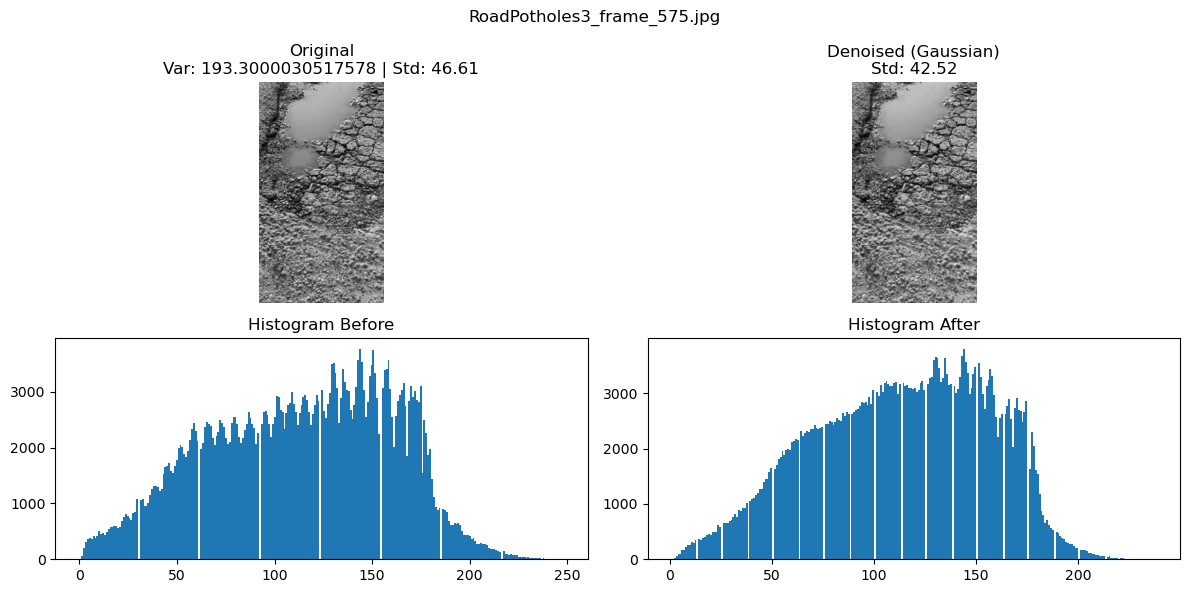

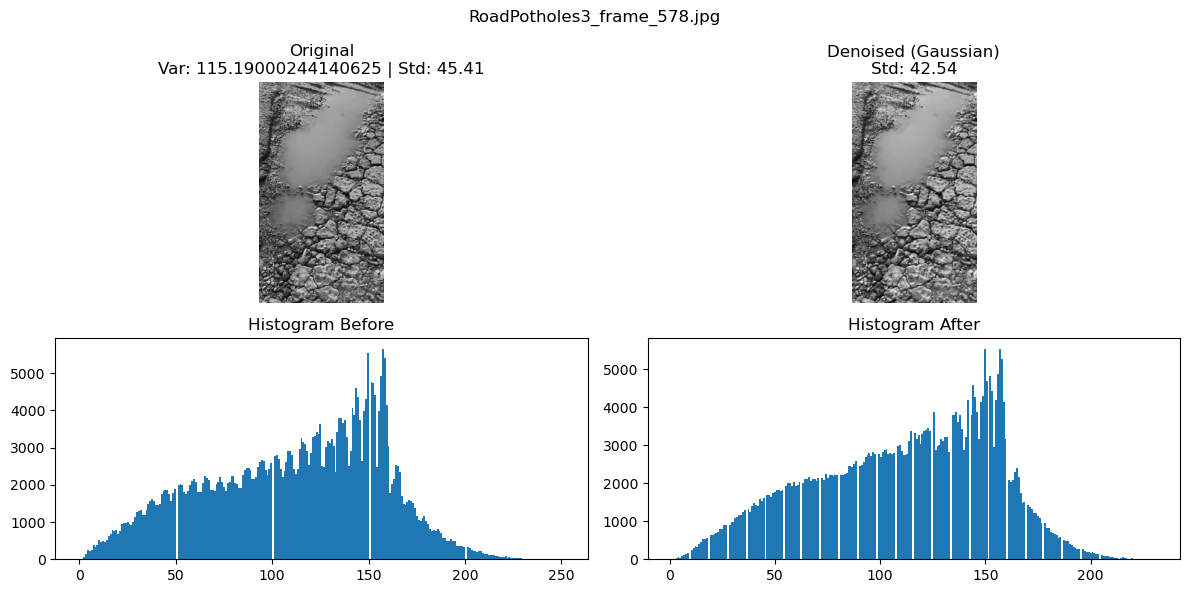

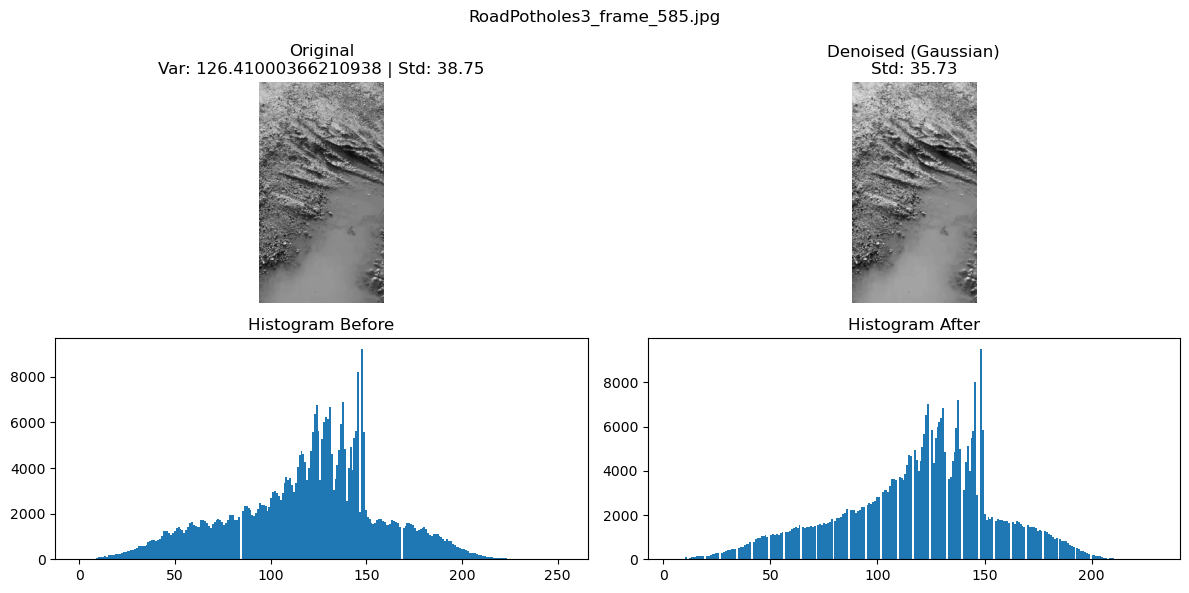

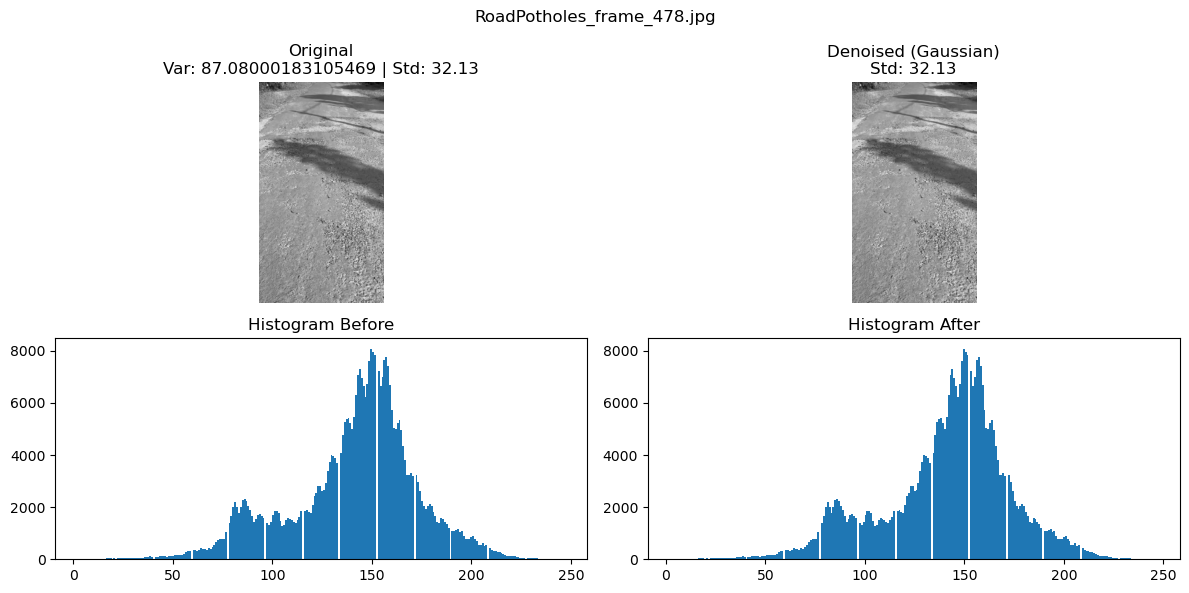

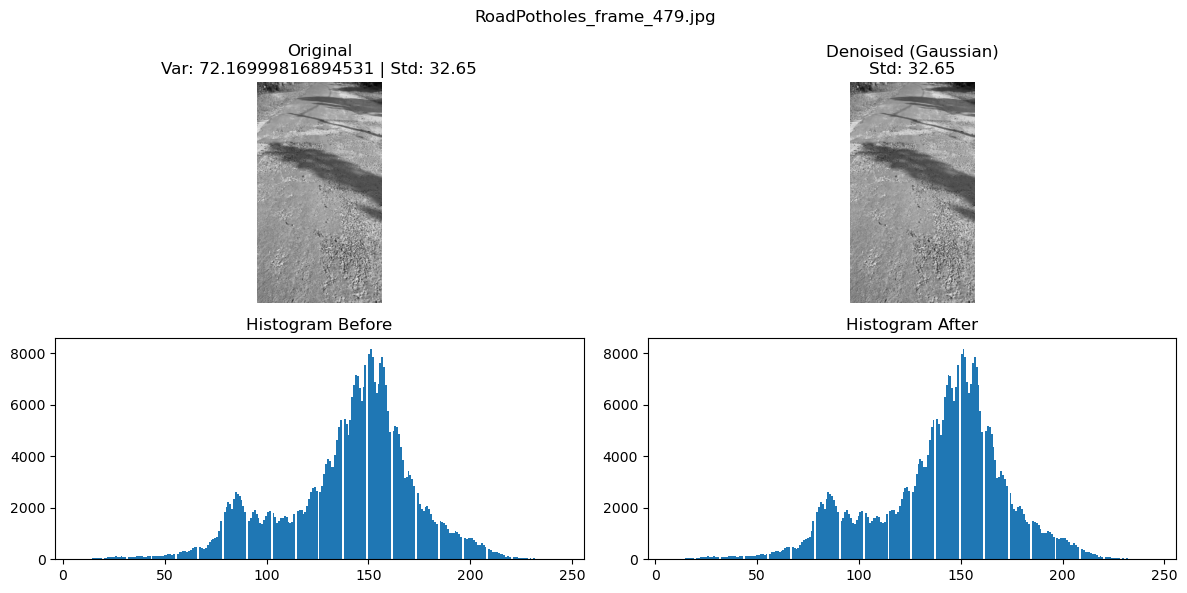

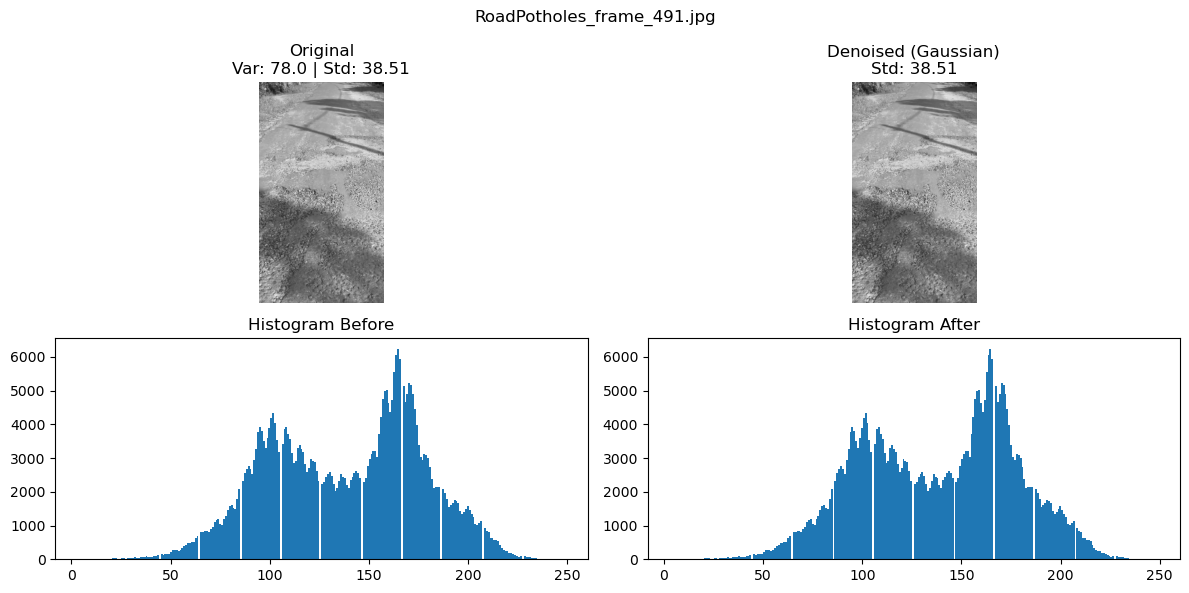

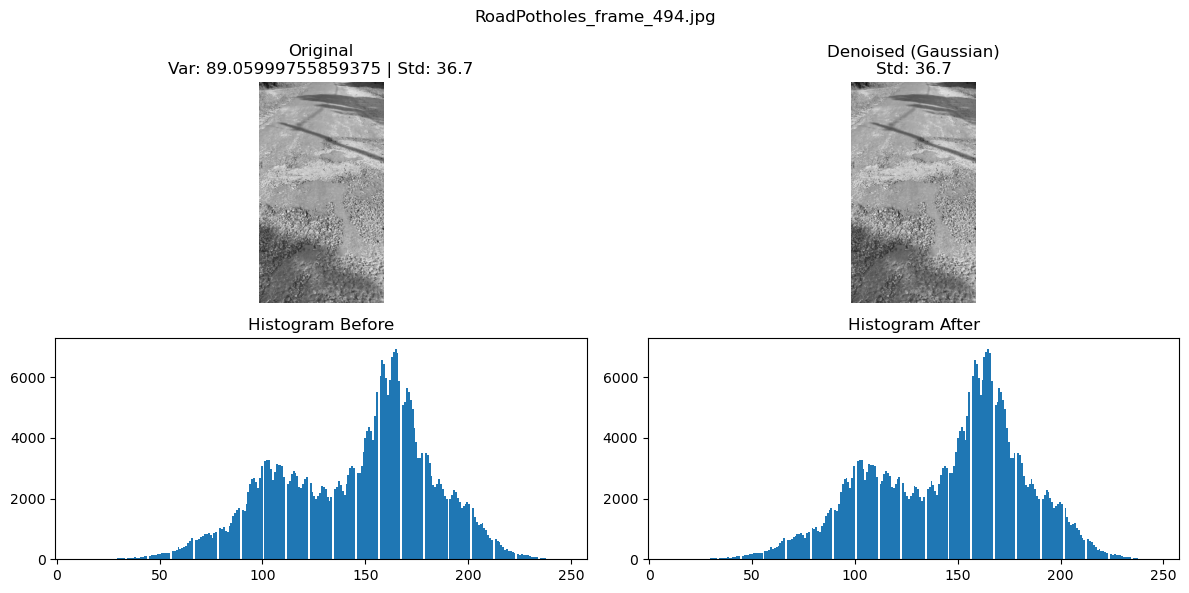

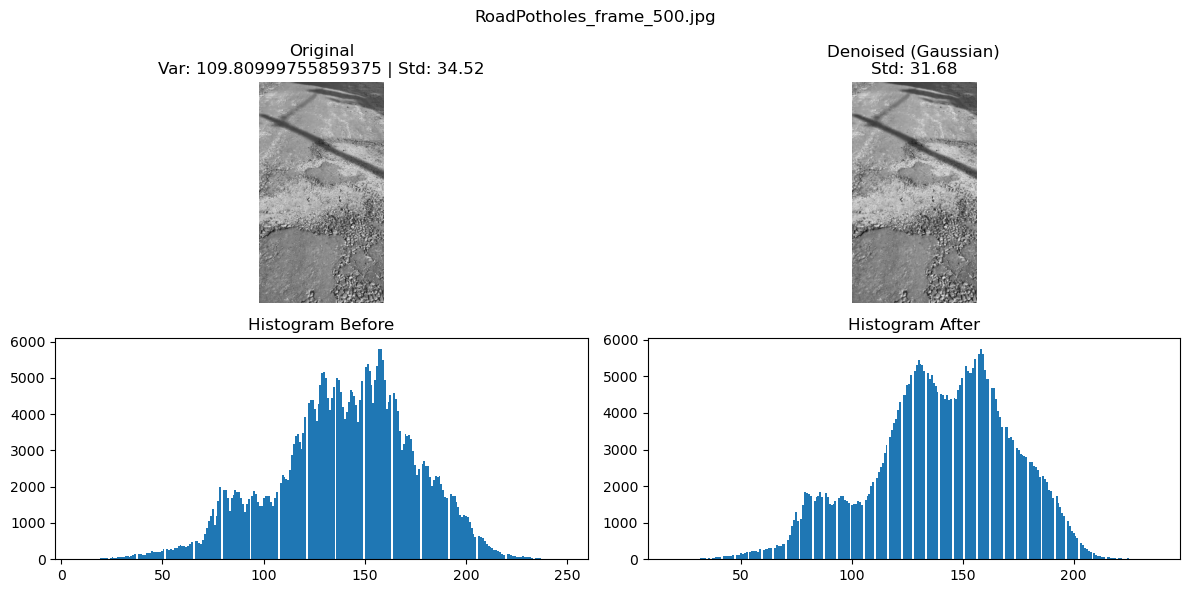

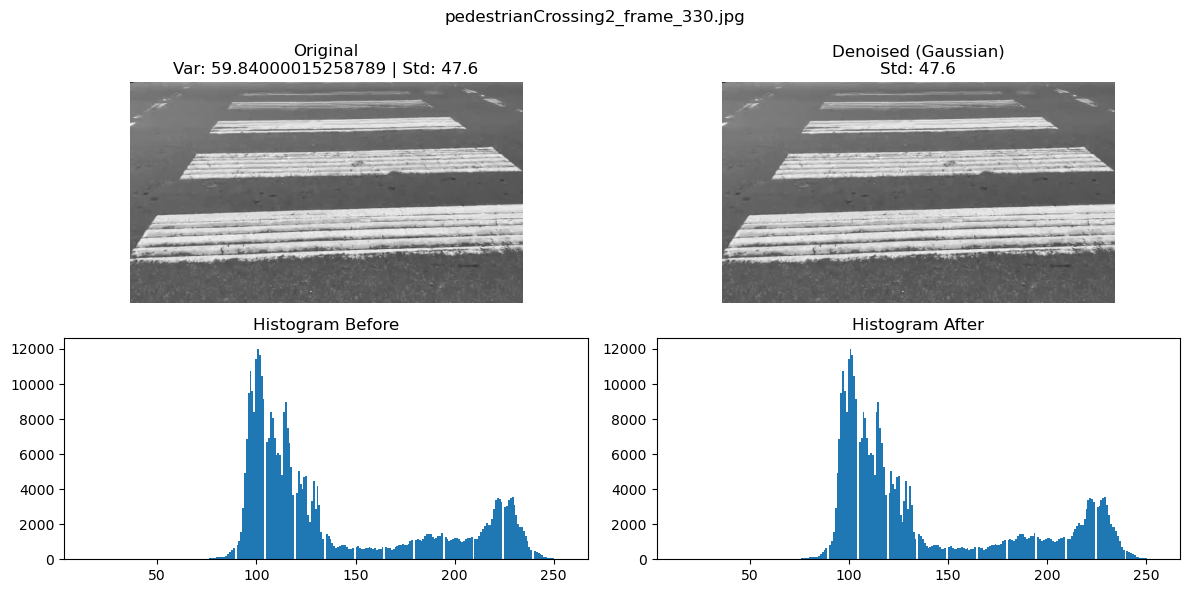

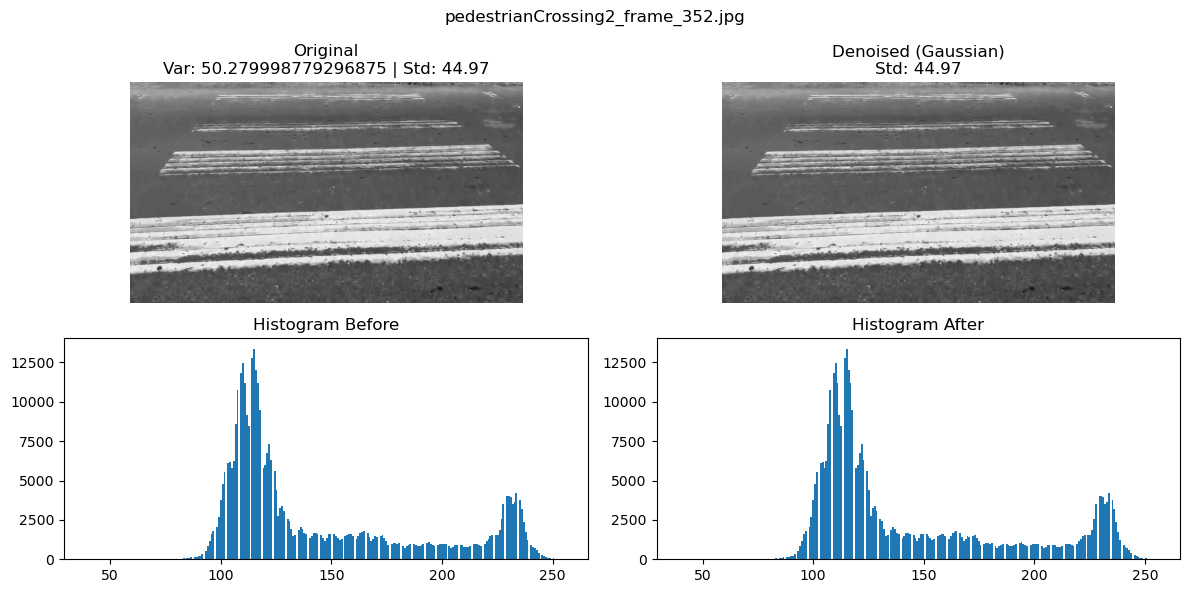

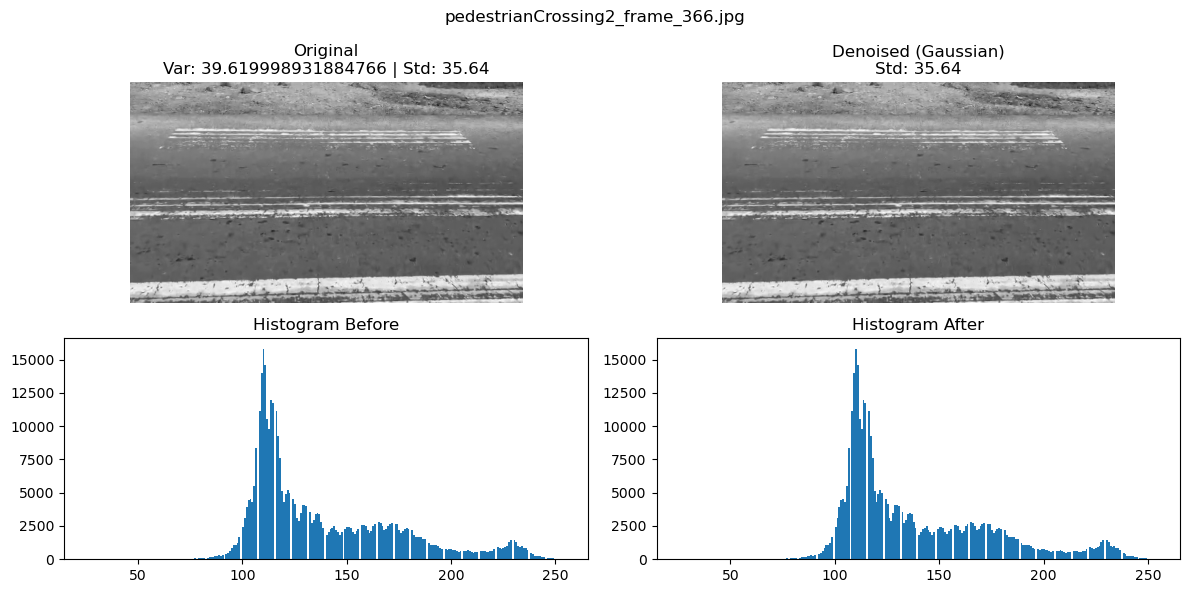

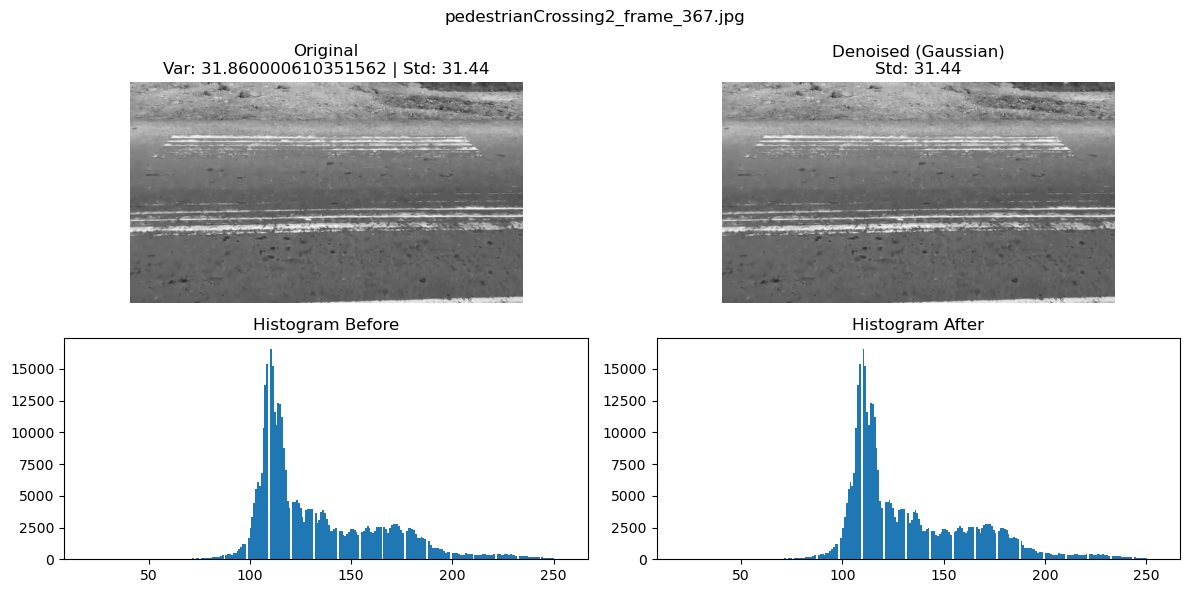


================ NOISE ANALYSIS TABLE ================

Frame                              Noise Type        Level     Variance    Std Before  Std After   Improvement 
---------------------------------------------------------------------------------------------------------------
AlligatorCracking_frame_0.jpg      Gaussian          Moderate  411.98      36.27       28.13       Yes         
AlligatorCracking_frame_20.jpg     Gaussian          Low       80.11       29.67       29.67       No          
AlligatorCracking_frame_35.jpg     Gaussian          Low       65.57       28.74       28.74       No          
AlligatorCracking_frame_4.jpg      Gaussian          Moderate  121.31      31.87       28.42       Yes         
AlligatorCracking_frame_51.jpg     Gaussian          Low       66.15       32.11       32.11       No          
AlligatorCracking_frame_9.jpg      Gaussian          Low       93.38       30.81       30.81       No          
EdgeCracking3_frame_72.jpg         Gaussian    

In [1]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

frames_folder = "frames"

def estimate_noise_variance(gray_image):
    blur = cv2.GaussianBlur(gray_image, (5, 5), 0)
    noise = gray_image.astype(np.float32) - blur.astype(np.float32)
    return np.var(noise)

def detect_salt_pepper(gray_image, threshold=0.02):
    total_pixels = gray_image.size
    extreme_pixels = np.sum((gray_image == 0) | (gray_image == 255))
    return (extreme_pixels / total_pixels) > threshold

def calculate_std(gray_image):
    return np.std(gray_image)

def show_results(original, denoised, file_name, noise_type, noise_var, std_before, std_after):

    plt.figure(figsize=(12,6))

    plt.subplot(2,2,1)
    plt.imshow(original, cmap="gray")
    plt.title(f"Original\nVar: {round(noise_var,2)} | Std: {round(std_before,2)}")
    plt.axis("off")

    plt.subplot(2,2,2)
    plt.imshow(denoised, cmap="gray")
    plt.title(f"Denoised ({noise_type})\nStd: {round(std_after,2)}")
    plt.axis("off")

    plt.subplot(2,2,3)
    plt.hist(original.ravel(), bins=256)
    plt.title("Histogram Before")

    plt.subplot(2,2,4)
    plt.hist(denoised.ravel(), bins=256)
    plt.title("Histogram After")

    plt.suptitle(file_name)
    plt.tight_layout()
    plt.show()

frame_files = sorted(os.listdir(frames_folder))

noise_values = []

for file in frame_files:
    if file.lower().endswith((".jpg", ".png", ".jpeg")):
        path = os.path.join(frames_folder, file)
        img = cv2.imread(path)

        if img is None:
            continue

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        noise_values.append(estimate_noise_variance(gray))

mean_noise = np.mean(noise_values)

display_count = 0
max_display = 30

results_table = []

for file in frame_files:

    if not file.lower().endswith((".jpg", ".png", ".jpeg")):
        continue

    path = os.path.join(frames_folder, file)
    img = cv2.imread(path)

    if img is None:
        continue

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    noise_var = estimate_noise_variance(gray)
    is_sp = detect_salt_pepper(gray)

    std_before = calculate_std(gray)

    noise_level = "Low" if noise_var < mean_noise else "Moderate"
    noise_type = "Salt & Pepper" if is_sp else "Gaussian"

    if noise_level == "Moderate":
        if is_sp:
            denoised = cv2.medianBlur(gray, 3)
        else:
            denoised = cv2.GaussianBlur(gray, (3,3), 0)
    else:
        denoised = gray.copy()

    std_after = calculate_std(denoised)

    improvement = "Yes" if std_after < std_before else "No"

    results_table.append([
        file,
        noise_type,
        noise_level,
        round(noise_var,2),
        round(std_before,2),
        round(std_after,2),
        improvement
    ])

    if display_count < max_display:
        show_results(gray, denoised, file, noise_type, noise_var, std_before, std_after)
        display_count += 1


print("\n================ NOISE ANALYSIS TABLE ================\n")

col_widths = [35, 18, 10, 12, 12, 12, 12]

header = ["Frame", "Noise Type", "Level", "Variance", "Std Before", "Std After", "Improvement"]

def format_row(row, widths):
    formatted = ""
    for i, item in enumerate(row):
        item = str(item)

        if i == 0 and len(item) > widths[i]:
            item = item[:widths[i]-3] + "..."

        formatted += item.ljust(widths[i])
    return formatted

# Print header
print(format_row(header, col_widths))
print("-" * sum(col_widths))

# Print rows
for row in results_table:
    print(format_row(row, col_widths))

print("\nNoise Analysis & Reduction Completed")